In [1]:
from scipy.io import loadmat

data = loadmat("../data/traffic_dataset.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tra_X_tr', 'tra_X_te', 'tra_Y_tr', 'tra_Y_te', 'tra_adj_mat'])


In [2]:
X_train = data['tra_X_tr']
y_train = data['tra_Y_tr']
X_test = data['tra_X_te']
y_test = data['tra_Y_te']

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1, 1261)
(36, 1261)
(1, 840)
(36, 840)


In [3]:
print(X_train[0])
print(y_train[0])

[<Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>             ...
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>
 <Compressed Sparse Column sparse array of dtype 'float64'
 	with 540 stored elements and shape (36, 48)>            ]
[0.05091079 0.04764129 0.04483886 ... 0.37132181 0.42456796 0.42269967]


In [4]:
import numpy as np

# Convert sparse matrices to dense arrays
X_train_dense = np.array([x.toarray() for x in X_train[0]])
X_test_dense = np.array([x.toarray() for x in X_test[0]])

print(X_train_dense.shape)
print(X_test_dense.shape)

(1261, 36, 48)
(840, 36, 48)


In [5]:
X_train_flat = X_train_dense.reshape(X_train_dense.shape[0], -1)
X_test_flat = X_test_dense.reshape(X_test_dense.shape[0], -1)

print(X_train_flat.shape)
print(X_test_flat.shape)

(1261, 1728)
(840, 1728)


In [6]:
y_train = y_train.T
y_test = y_test.T

print(y_train.shape)
print(y_test.shape)

(1261, 36)
(840, 36)


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train)

# Predict
y_pred = rf_model.predict(X_test_flat)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.03155390273422151
RMSE: 0.04711057802210075
R2: 0.914121173201282


In [9]:
print(y_pred.shape)
print(y_pred[:2])

(840, 36)
[[0.40808968 0.5812284  0.3437646  0.37474078 0.23719757 0.2329986
  0.26182625 0.27540402 0.6116114  0.72671182 0.64237739 0.48555815
  0.62405885 0.64450724 0.7632695  0.24602989 0.20630079 0.214227
  0.22266698 0.28682391 0.26659505 0.31538066 0.25208314 0.19428305
  0.12963568 0.56922466 0.35431107 0.19827184 0.22926203 0.71074264
  0.21479682 0.20167212 0.05566558 0.13821579 0.2037646  0.72697338]
 [0.39439514 0.64866885 0.36632415 0.39406352 0.29137786 0.29035497
  0.33239608 0.31696871 0.61252219 0.71332088 0.64707146 0.48961233
  0.61828585 0.63412424 0.75798692 0.27836525 0.24725362 0.24528258
  0.25911723 0.33387669 0.31042971 0.35938347 0.3102709  0.24936478
  0.16769734 0.70786081 0.35812704 0.24779542 0.25126109 0.77477814
  0.25914526 0.24868753 0.07120972 0.17074731 0.25198038 0.78103223]]


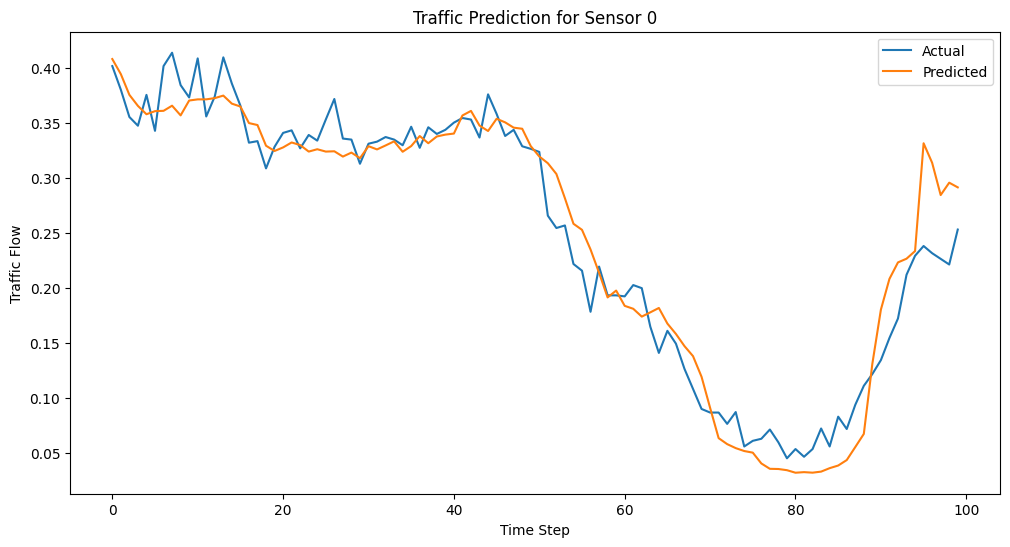

In [10]:
import matplotlib.pyplot as plt

# choose one sensor to visualize
sensor_idx = 0

plt.figure(figsize=(12, 6))
plt.plot(y_test[:100, sensor_idx], label="Actual")
plt.plot(y_pred[:100, sensor_idx], label="Predicted")
plt.title(f"Traffic Prediction for Sensor {sensor_idx}")
plt.xlabel("Time Step")
plt.ylabel("Traffic Flow")
plt.legend()
plt.show()

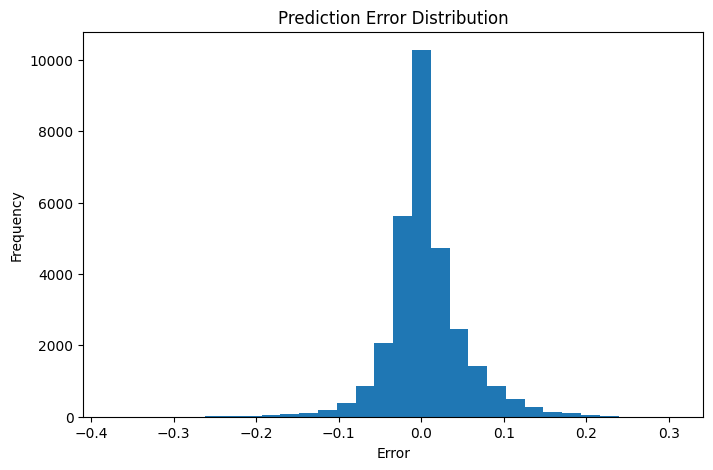

In [11]:
errors = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.hist(errors.flatten(), bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

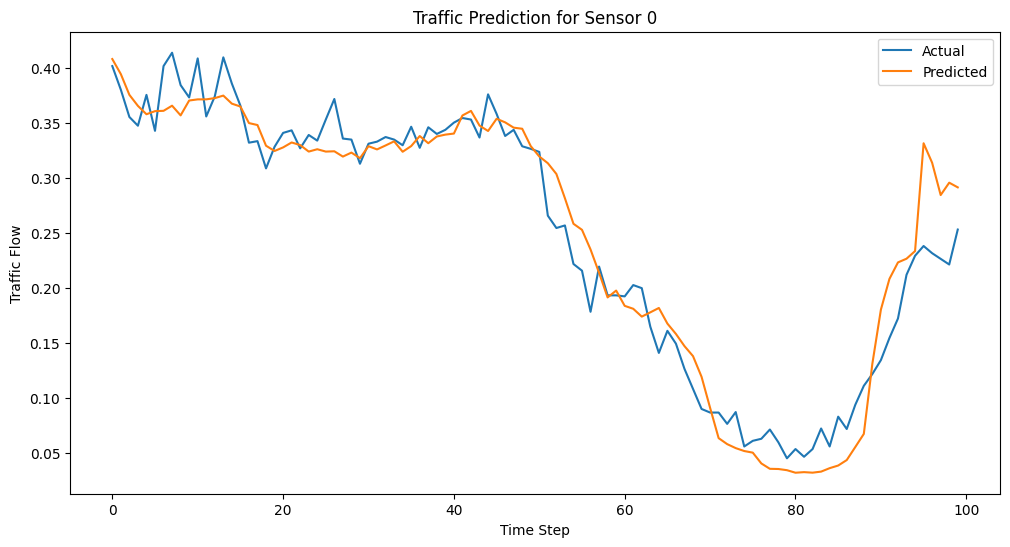

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(y_test[:100, sensor_idx], label="Actual")
plt.plot(y_pred[:100, sensor_idx], label="Predicted")
plt.title(f"Traffic Prediction for Sensor {sensor_idx}")
plt.xlabel("Time Step")
plt.ylabel("Traffic Flow")
plt.legend()
plt.savefig("../outputs/sensor_0_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

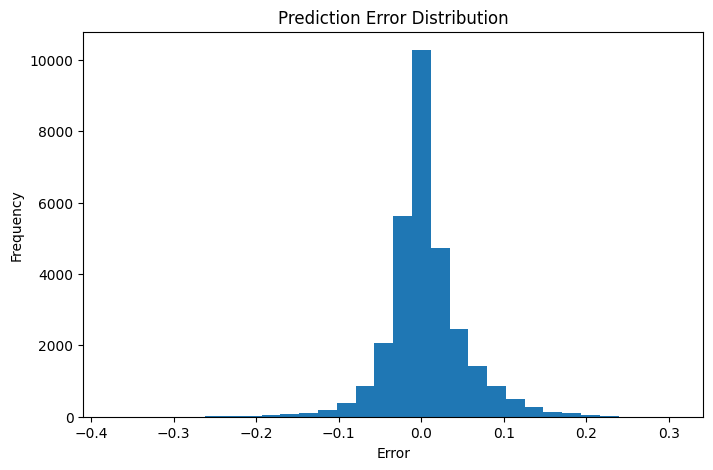

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(errors.flatten(), bins=30)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.savefig("../outputs/error_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
import pandas as pd

def recommend_green_time(flow):
    if flow < 0.25:
        return 30
    elif flow < 0.5:
        return 45
    elif flow < 0.75:
        return 60
    else:
        return 90

def congestion_label(flow):
    if flow < 0.25:
        return "Low"
    elif flow < 0.5:
        return "Moderate"
    elif flow < 0.75:
        return "High"
    else:
        return "Severe"

sensor_idx = 0

results_df = pd.DataFrame({
    "actual_flow": y_test[:, sensor_idx],
    "predicted_flow": y_pred[:, sensor_idx]
})

results_df["congestion_level"] = results_df["predicted_flow"].apply(congestion_label)
results_df["recommended_green_time"] = results_df["predicted_flow"].apply(recommend_green_time)

print(results_df.head(10))

   actual_flow  predicted_flow congestion_level  recommended_green_time
0     0.401681        0.408090         Moderate                      45
1     0.380196        0.394395         Moderate                      45
2     0.355441        0.375553         Moderate                      45
3     0.347501        0.365521         Moderate                      45
4     0.375525        0.357926         Moderate                      45
5     0.342830        0.360738         Moderate                      45
6     0.401681        0.361032         Moderate                      45
7     0.413825        0.365694         Moderate                      45
8     0.384400        0.356899         Moderate                      45
9     0.373190        0.370397         Moderate                      45


In [16]:
results_df.to_csv("../outputs/sensor_0_signal_recommendations.csv", index=False)